In [1]:
from __future__ import division, print_function, absolute_import

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

import os
import importlib

from tensorflow import keras
from tensorflow.keras import layers
from scipy import signal

import generate_lorentz as gl
import generate_data as gd
import classify_data as cd
import efficient_data_generation as ed
import data_spy as ds
import sliding_window as sw

importlib.reload(cd)
importlib.reload(ed)
importlib.reload(ds)
importlib.reload(gl)
importlib.reload(sw)

<module 'sliding_window' from '/home/gabriel/Insync/gpe@berkeley.edu/Google Drive/Seconcephalon/Projects/LEPRECHAUN/Analytis Laboratory/ML Peak Tracker/sliding_window.py'>

In [2]:
F = np.linspace(0,1,1024)
plt.rcParams['figure.figsize'] = 50, 5

[[1. 1. 1. 1. 0.]]


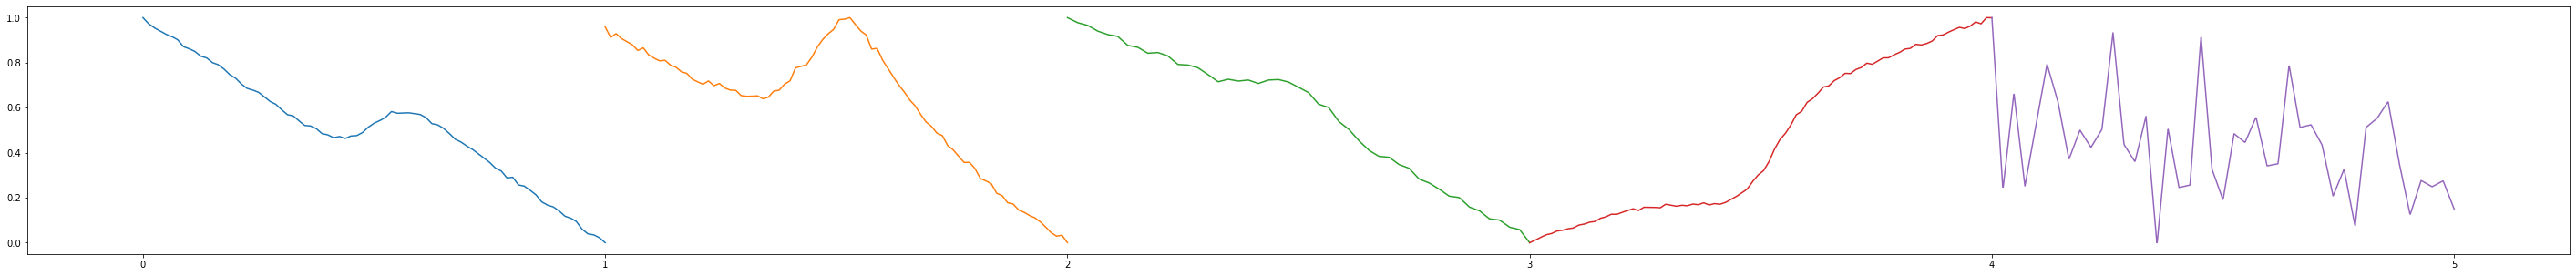

In [28]:
(label, data) = ed.make_single_data_set(5, noise=True)
print(np.transpose(label))
for i in range(0, len(label)):
    plt.plot(F + i, data[i])

In [10]:
# Train data if making new model
sing_train = ed.make_single_data_set(100000)

Generating Data: [########################################] 1000/1000

In [ ]:
# Test data needed to evaluate new or existing model
sing_test = ed.make_single_data_set(1000)

In [3]:
sing_model = keras.Sequential([
    keras.layers.Flatten(),
    keras.layers.Dense(1024, activation='relu'),
    # keras.layers.Dense(1024, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    keras.layers.Dense(2, activation='softmax')
])

Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


In [ ]:
# Alternatively, load the existing model that's already been generated
root = os.getcwd()
model_dir = os.path.join(root, 'models')
sing_model = keras.models.load_model(os.path.join(model_dir, 'sing_model_3'))

In [14]:
# Be sure to compile model before using it
sing_model.compile(optimizer='Adadelta',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [5]:
# Fit model to new or additional data if you want
sing_model.fit(sing_train[1], sing_train[0], epochs=100)

Epoch 1/100
50000/50000 [==============================] - 6s 111us/sample - loss: 0.6653 - acc: 0.6255
Epoch 2/100
50000/50000 [==============================] - 5s 109us/sample - loss: 0.6235 - acc: 0.7352
Epoch 3/100
50000/50000 [==============================] - 5s 109us/sample - loss: 0.5987 - acc: 0.7816
Epoch 4/100
50000/50000 [==============================] - 5s 109us/sample - loss: 0.5770 - acc: 0.8189
Epoch 5/100
50000/50000 [==============================] - 5s 110us/sample - loss: 0.5575 - acc: 0.8477
Epoch 6/100
50000/50000 [==============================] - 5s 110us/sample - loss: 0.5402 - acc: 0.8680
Epoch 7/100
50000/50000 [==============================] - 6s 110us/sample - loss: 0.5248 - acc: 0.8826
Epoch 8/100
50000/50000 [==============================] - 5s 110us/sample - loss: 0.5113 - acc: 0.8924
Epoch 9/100
50000/50000 [==============================] - 5s 110us/sample - loss: 0.4994 - acc: 0.8993
Epoch 10/100
50000/50000 [==============================] - 6s 1

In [15]:
sing_loss, sing_acc = sing_model.evaluate(sing_test[1], sing_test[0])

1000/1000 [==============================] - 0s 69us/sample - loss: 0.3227 - acc: 0.9960


In [502]:
bg, l, f, v = gl.generate_normalized_data(max_num_lorentz=10)

In [503]:
regions = sw.slide_scale(sing_model, v, num_zooms=7, min_zoom=5, overlap=1/4, zoom_level=2, confidence_tolerance=0.85, merge_tolerance=0.6, compress=True)
def plot_region(i, color=None):
    min_f = int(regions[i][0])
    max_f = int(regions[i][1])
    if color is None:
        plt.plot(f[min_f:max_f], v[min_f:max_f])
    else:
        plt.plot(f[min_f:max_f], v[min_f:max_f], color=color)

[[ 24. 340. 484. 632. 664. 716. 820. 856. 924.]
 [160. 356. 500. 648. 752. 807. 836. 880. 939.]]


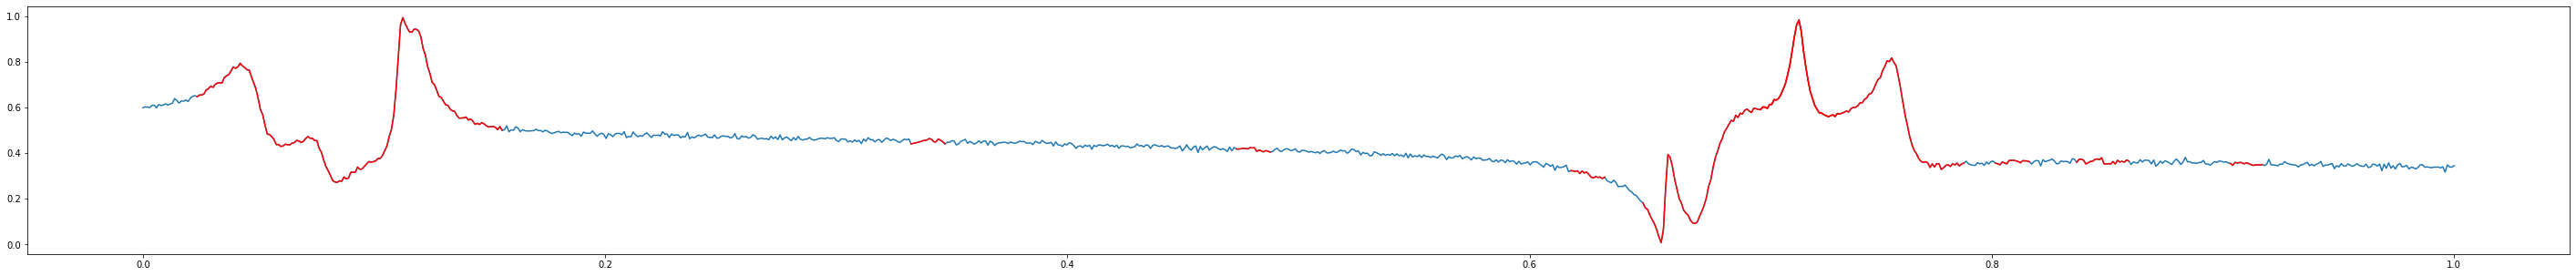

In [504]:
plt.plot(f, v)
for i in range(0, len(regions)):
    plot_region(i)
print(np.transpose(regions))

In [260]:
sing_model.save(os.path.join(os.path.join(os.getcwd(), 'models'), 'sing_model_2'))